In [1]:
# Install necessary libraries
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 20.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. 

In [12]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt

In [2]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
            'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour', 'vessel_type']
target = 'TravelTime_seconds'

<ipython-input-2-6b9069eb52ab>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [3]:
# Split data into train and test sets
train_data, test_data = train_test_split(data[features + [target]], test_size=0.2, random_state=42)

# Define hyperparameter search space for AutoGluon
hyperparameters = {
    'GBM': [
        {'num_boost_round': 100, 'learning_rate': 0.1},
        {'num_boost_round': 200, 'learning_rate': 0.05},
    ],
    'CAT': [
        {'iterations': 500, 'learning_rate': 0.05},
        {'iterations': 1000, 'learning_rate': 0.01},
    ],
    'XGB': [
        {'n_estimators': 300, 'max_depth': 7},
        {'n_estimators': 500, 'max_depth': 5},
    ],
    'NN_TORCH': [
        {'epochs': 50, 'learning_rate': 1e-3},
        {'epochs': 100, 'learning_rate': 1e-4},
    ],
}

# Train AutoGluon model with Hyperparameter Tuning
tuned_predictor = TabularPredictor(
    label=target,
).fit(
    train_data,
    hyperparameters=hyperparameters,
    presets="best_quality",
    time_limit=1200
)

No path specified. Models will be saved in: "AutogluonModels/ag-20250113_145437"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024
CPU Count:          2
Memory Avail:       11.33 GB / 12.67 GB (89.4%)
Disk Space Avail:   74.21 GB / 107.72 GB (68.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be f

In [4]:
# Predict on the test set
ag_y_pred_tuned = tuned_predictor.predict(test_data[features])

# Evaluate the tuned model
ag_mae_tuned = mean_absolute_error(test_data[target], ag_y_pred_tuned)
ag_mse_tuned = mean_squared_error(test_data[target], ag_y_pred_tuned)
ag_r2_tuned = r2_score(test_data[target], ag_y_pred_tuned)

print("AutoGluon Tabular Model Performance with Hyperparameter Tuning:")
print("Mean Absolute Error:", ag_mae_tuned)
print("Mean Squared Error:", ag_mse_tuned)
print("R-squared:", ag_r2_tuned)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


AutoGluon Tabular Model Performance with Hyperparameter Tuning:
Mean Absolute Error: 5171.394649873469
Mean Squared Error: 465349156.2977104
R-squared: 0.9965637566400155


In [13]:
# Define features (X) and target (y)
X = data[features]
y = data[target]

# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(X, y, kf):
    mae_scores = []
    mse_scores = []
    r2_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Combine features and target into a single DataFrame for AutoGluon
        train_data = pd.concat([X_train, y_train], axis=1)
        test_data = pd.concat([X_test, y_test], axis=1)

        # Train AutoGluon model
        predictor = TabularPredictor(label=target).fit(train_data, time_limit=600, presets='best_quality')

        # Predict on the test set
        y_pred = predictor.predict(X_test)

        # Calculate metrics
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        mse_scores.append(mean_squared_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))

    return mae_scores, mse_scores, r2_scores

# Perform K-Fold Cross-Validation
mae_scores, mse_scores, r2_scores = evaluate_model(X, y, kf)

# Print results
print(f'MAE Scores: {mae_scores}')
print(f'MSE Scores: {mse_scores}')
print(f'R2 Scores: {r2_scores}')
print(f'Mean MAE: {sum(mae_scores)/len(mae_scores)}')
print(f'Mean MSE: {sum(mse_scores)/len(mse_scores)}')
print(f'Mean R2: {sum(r2_scores)/len(r2_scores)}')

No path specified. Models will be saved in: "AutogluonModels/ag-20250113_151500"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024
CPU Count:          2
Memory Avail:       10.53 GB / 12.67 GB (83.1%)
Disk Space Avail:   74.16 GB / 107.72 GB (68.8%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be f

MAE Scores: [5501.440609183537, 3932.969980978623, 6086.396129545152, 3587.0603023441663, 4049.927984695577]
MSE Scores: [486508027.6915039, 366065833.35211575, 436641414.22530633, 227629559.52488393, 287937139.5989689]
R2 Scores: [0.9964075147507853, 0.997455927728201, 0.9970171253482596, 0.9983192381477329, 0.9980173795180116]
Mean MAE: 4631.559001349411
Mean MSE: 360956394.8785558
Mean R2: 0.9974434370985982


In [14]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for AutoGluon
ag_mape_tuned = mean_absolute_percentage_error(test_data[target], ag_y_pred_tuned)
print(f"AutoGluon Tabular MAPE: {ag_mape_tuned:.2f}%")

AutoGluon Tabular MAPE: 1.17%


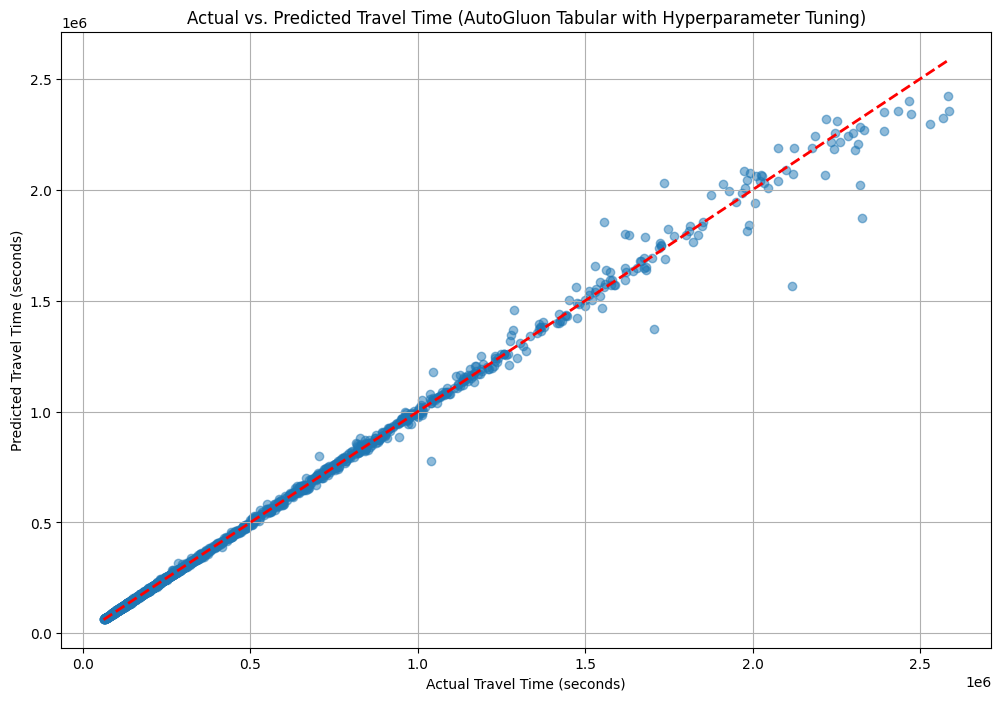

In [15]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(test_data[target], ag_y_pred_tuned, alpha=0.5)
plt.plot([min(test_data[target]), max(test_data[target])], [min(test_data[target]), max(test_data[target])], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (AutoGluon Tabular with Hyperparameter Tuning)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()

Computing feature importance via permutation shuffling for 12 features using 3754 rows with 5 shuffle sets...
	95.48s	= Expected runtime (19.1s per shuffle set)
	78.65s	= Actual runtime (Completed 5 of 5 shuffle sets)


Feature Importance:
                       importance       stddev       p_value  n  \
Average_Speed_Kmph  420316.068112  5420.237444  3.317831e-09  5   
Voyage_Distance_Km  222761.832084  3610.204032  8.275477e-09  5   
LATa                   934.350718   304.345786  1.179073e-03  5   
DepartureHour          227.178319    31.404193  4.272472e-05  5   
LONd                   200.622305    78.367532  2.304848e-03  5   
vessel_type            148.844863   145.870406  4.231556e-02  5   
draft_km               -49.430327   240.764778  6.649910e-01  5   
breadthKM              -77.761948   140.983698  8.575151e-01  5   
Avg_Course             -91.889503   165.401707  8.590011e-01  5   
Std_SpeedKMpH         -180.978016   156.018493  9.697790e-01  5   
LONa                  -268.465923    57.382084  9.997641e-01  5   
LATd                  -431.489621   233.752849  9.927389e-01  5   

                         p99_high        p99_low  
Average_Speed_Kmph  431476.411924  409155.724300  
Voyage

<Figure size 1200x800 with 0 Axes>

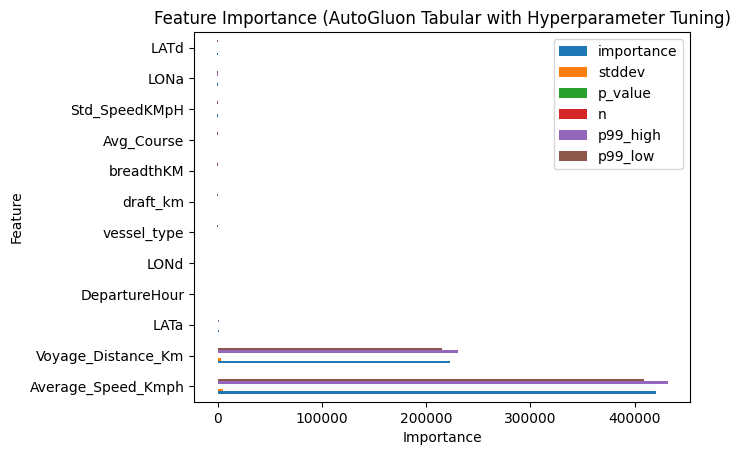

In [16]:
# Feature Importance
feature_importance = tuned_predictor.feature_importance(test_data)
print("Feature Importance:")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(12, 8))
feature_importance.plot(kind='barh')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (AutoGluon Tabular with Hyperparameter Tuning)')
plt.show()